# SFace — test minimal + webcam

In [1]:
%pip install -q opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import urllib.request   # for downloading models 
from pathlib import Path    # for handling file paths
import cv2, numpy as np     # for computer vision and numerical operations
import matplotlib.pyplot as plt # for displaying images

MODELS = Path("models"); MODELS.mkdir(exist_ok=True) 
URLS = {
    "yunet.onnx": "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx",
    "sface.onnx": "https://github.com/opencv/opencv_zoo/raw/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx",
}
for name, url in URLS.items(): # download models if not exist
    if not (MODELS / name).exists():
        urllib.request.urlretrieve(url, MODELS / name)

detector = cv2.FaceDetectorYN.create(str(MODELS / "yunet.onnx"), "", (320, 320), 0.6, 0.3, 5000) # create face detector with specified parameters
recognizer = cv2.FaceRecognizerSF.create(str(MODELS / "sface.onnx"), "") # create face recognizer with specified model
COS_THR = 0.3 # cosine similarity threshold for face recognition, determined empirically

def detect(img): # detect the most confident face in the image and return its bounding box and landmarks
    h, w = img.shape[:2]
    detector.setInputSize((w, h))
    _, faces = detector.detect(img)
    return None if faces is None else faces[np.argmax(faces[:, -1])]

def embed(img): # extract face embedding from the image
    f = detect(img)
    if f is None: return None
    return recognizer.feature(recognizer.alignCrop(img, f))

def cosine(a, b): # calculate cosine similarity between two face embeddings
    return recognizer.match(a, b, cv2.FaceRecognizerSF_FR_COSINE)

print("OK")

OK


## Construire la base à partir de `data/`

In [3]:
DATA = Path("data")

# Convention: nom de fichier (sans extension) = nom de la personne.
# Ex: data/alice.jpg -> "alice"
db = {}
for p in sorted(DATA.iterdir()):
    if p.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp"}:
        continue
    img = cv2.imread(str(p))
    emb = embed(img)
    if emb is None:
        print(f"[skip] aucun visage trouvé dans {p.name}")
        continue
    db[p.stem] = emb
    print(f"[ok]   {p.stem}")

print(f"\n{len(db)} personne(s) dans la base: {list(db)}")

[ok]   Elie
[ok]   Mohamad
[ok]   img1
[ok]   img11
[ok]   img12
[ok]   img2
[ok]   img3

7 personne(s) dans la base: ['Elie', 'Mohamad', 'img1', 'img11', 'img12', 'img2', 'img3']


## Reconnaissance multi-visages sur la frame

Détecte tous les visages, compare chacun à la base. Si match → nom, sinon → `Unknown`.

détection :   51.2 ms
reco+draw :   19.7 ms  (2 visage(s))
total     :   71.0 ms


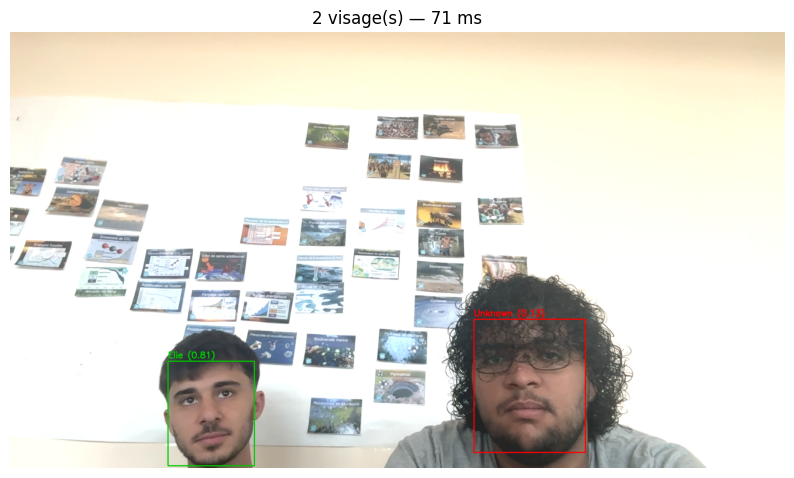

In [4]:
import time

cap = cv2.VideoCapture(0)
# warm-up : la 1ère frame est souvent sombre, l'auto-exposure met qq frames à se stabiliser
for _ in range(15):
    ok, frame = cap.read()
cap.release()
assert ok, "webcam KO"

# coup de boost : luminosité (+30) et contraste (1.15x)
frame = cv2.convertScaleAbs(frame, alpha=1.15, beta=30)

t0 = time.perf_counter()

h, w = frame.shape[:2]
detector.setInputSize((w, h))
t_det = time.perf_counter()
_, faces = detector.detect(frame)
t_det = (time.perf_counter() - t_det) * 1000

t_rec = time.perf_counter()
annotated = frame.copy()
if faces is not None:
    for face in faces:
        feat = recognizer.feature(recognizer.alignCrop(frame, face))

        best_name, best_cos = "Unknown", -1.0
        for name, ref in db.items():
            c = cosine(ref, feat)
            if c > best_cos:
                best_name, best_cos = name, c
        if best_cos < COS_THR:
            best_name = "Unknown"

        x, y, fw, fh = face[:4].astype(int)
        color = (0, 200, 0) if best_name != "Unknown" else (0, 0, 255)
        cv2.rectangle(annotated, (x, y), (x + fw, y + fh), color, 2)
        label = f"{best_name} ({best_cos:.2f})"
        cv2.putText(annotated, label, (x, max(0, y - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
t_rec = (time.perf_counter() - t_rec) * 1000
t_total = (time.perf_counter() - t0) * 1000

n = 0 if faces is None else len(faces)
print(f"détection : {t_det:6.1f} ms")
print(f"reco+draw : {t_rec:6.1f} ms  ({n} visage(s))")
print(f"total     : {t_total:6.1f} ms")

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title(f"{n} visage(s) — {t_total:.0f} ms")
plt.show()